Universidade Federal do Rio Grande do Sul (UFRGS)   
Programa de Pós-Graduação em Engenharia Civil (PPGEC)   

# PEC00025: Introduction to Vibration Theory


## Test P2 (2026/1): Discrete and continuous mdof systems

---

**NAME:** <br/>
**CARD:** 



In [7]:
# Importing Python modules required for this notebook
# (this cell must be executed with "shift+enter" before any other Python cell)

import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import *



In [8]:
def vibration_modes(D, M):

# Uses scipy to solve the eigenvalue problem (with dynamic matrix D)
    l2, Phi = sc.eig(D)
    w2  = 1/l2

# Ensure ascending order of eigenvalues
    iw  = w2.argsort()
    w2  = w2[iw]
    Phi = Phi[:,iw]
    
# Eigenvalues to vibration frequencies
    wk  = np.sqrt(np.real(w2)) 
    fk  = wk/2/np.pi

# Mass matrix normalization (Mk = 1 for all k)
    for k in range(len(wk)):
        Mk       = np.sum(np.diag(M)*Phi[:,k]*Phi[:,k])
        Phi[:,k] = Phi[:,k]/np.sqrt(Mk)

    return fk, wk, Phi


## Questão 1:

O sistema discreto é composto de duas massas com $m = 100{\rm kg}$ e três molas com $k =  4{\rm kN/m}$. 
Os dois graus de liberdade correspondem ao deslocamento vertical de cada massa, $u_1(t)$ e $u_1(t)$. 
O amortecimento em todos os modos de vibração é 1%.

<img src="resources/tests/PEC00025A_261_P2_Q1.png" alt="PEC00025A_261_Q1" width="240px"/>

### Questão 1a (sistema discreto, vibração livre):

Calcule e represente graficamente os modos de vibração e respectivas frequências naturais de vibração livre. (2.5pts)

### _Solução_:

Vamos inicialmente construir a matriz de rigidez conforme o método dos deslocamento e a matriz
de massas concentradas.


In [9]:
K = 4000*np.array([[ 2, -1], [ -1,  2]], dtype=float)
M =  100*np.array([[ 1,  0], [  0,  1]], dtype=float)

Uma vez definidas as matrizes, resolvemos o problema de autovalores e autovetores.

In [10]:
H  =  np.linalg.inv(K)
D  =  np.matmul(H, M)

fk, wk, Phi = vibration_modes(D, M)

np.set_printoptions(formatter={'float': '{:8.5f}'.format})
print('\033[1mMatriz dinâmica D (x 1e3)\033[0m')
print(1e3*D,'\n')

np.set_printoptions(formatter={'float': '{:8.5f}'.format})
print('\033[1mMatriz de formas modais Φ \033[0m')
print(Phi,'\n')

print('Frequência modo 1: {0:6.2f} Hz = {1:6.2f} rad/s  '.format(fk[0], wk[0]))
print('Frequência modo 2: {0:6.2f} Hz = {1:6.2f} rad/s\n'.format(fk[1], wk[1]))


Matriz dinâmica D (x 1e3)
[[16.66667  8.33333]
 [ 8.33333 16.66667]] 

Matriz de formas modais Φ 
[[ 0.07071 -0.07071]
 [ 0.07071  0.07071]] 

Frequência modo 1:   1.01 Hz =   6.32 rad/s  
Frequência modo 2:   1.74 Hz =  10.95 rad/s



Por fim, vamos visualizar as duas formas modais conforme o resultado acima.

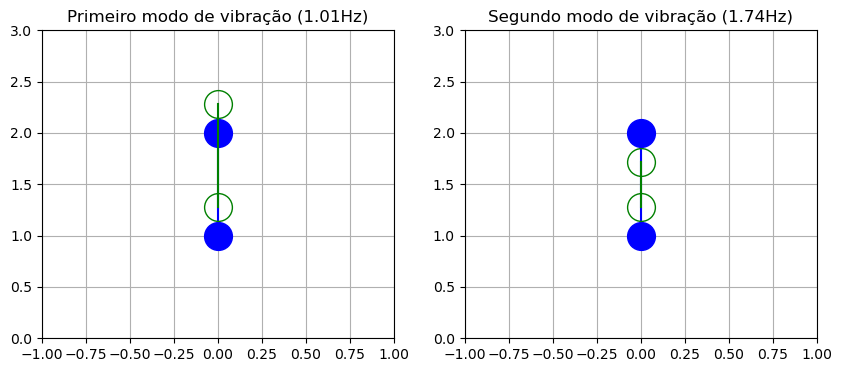

In [11]:
pos = np.array([2, 1])
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot([0, 0], pos, 'bo-', markersize=20)
plt.plot([0, 0], pos+4*Phi[:,0], 'go-', markerfacecolor='none', markersize=20)
plt.axis([-1, 1, 0, 3])
plt.title(f'Primeiro modo de vibração ({fk[0]:.2f}Hz)')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot([0, 0], pos, 'bo-', markersize=20)
plt.plot([0, 0], pos+4*Phi[:,1], 'go-', markerfacecolor='none', markersize=20)
plt.axis([-1, 1, 0, 3])
plt.title(f'Segundo modo de vibração ({fk[1]:.2f}Hz)')
plt.grid(True)


### Questão 1b (sistema discreto, vibração forçada):

A gravidade $g \approx 9.81{\rm m/s^2}$ é "ligada" subitamente, tal como uma função passo unitário. 
Usando superposição modal, calcule as amplitudes e faça o gráfico do deslocamento $u_2(t)$. (2.5pts)

### _Solução_:

A gravidade implica em um vetor peso atuando nas duas massas simultaneamente. 
Vamos então construir esse vetor e a partir dele construir as forças modais nos dois primeiros modos.
As forças modais serão usadas para construir um objeto ```MRPy``` com duração de 30s (tempo de integração) discretizados em 4096 passos de tempo. 


In [12]:
g  = 9.81

F  = g*np.matmul(M, np.ones((2, 4096)))
Fk = MRPy(np.matmul(Phi.T, F), Td=30.)


A questão será resolvida numericamente, para os dois modos de vibração.
Para usarmos o método ```sdof_Duhamel``` precisamos dividir as forças modais 
pelas massas modais. 

In [13]:
Mk1 = np.dot(Phi[:,0], np.dot(M, Phi[:,0]))
Mk2 = np.dot(Phi[:,1], np.dot(M, Phi[:,1]))

print('Massa modal no primeiro modo: {0:6.2f} kg  '.format(Mk1))
print('Massa modal no segundo modo:  {0:6.2f} kg\n'.format(Mk2))


Massa modal no primeiro modo:   1.00 kg  
Massa modal no segundo modo:    1.00 kg



Observa-se que a função que faz a análise modal já normalizou as formas modais pela matriz de massa, portanto as massas modais são todas unitárias.

Assim, os deslocamentos modais são obtidos abaixo com amortecimento de 1%.

In [14]:
uk = Fk.sdof_Duhamel(fk, 0.01)

O deslocamento $u_2(t)$ resulta portanto:

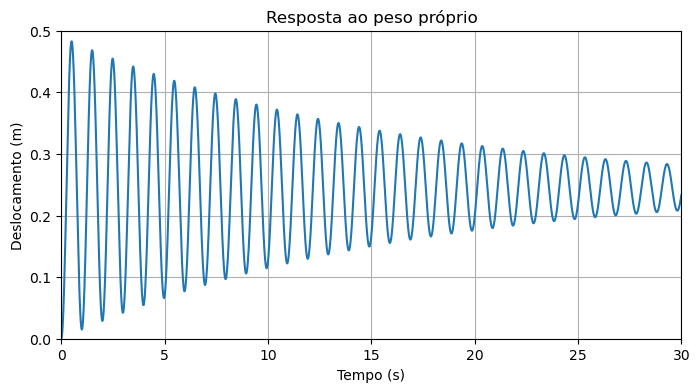

In [15]:
u = np.dot(Phi, uk)
t = uk.t_axis()

plt.figure(figsize=(8,4))
plt.plot(t, u[1,:])

plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (m)')
plt.title('Resposta ao peso próprio')
plt.axis([0, 30, 0, 0.5])
plt.grid()
plt.show()

Observe que a solução estática, para a qual a solução dinâmica converge, é:

In [16]:
Fe = 100*g*np.array([[1],[1]])   # peso como força estática
ue = np.linalg.solve(K, Fe)      # solução estática para peso próprio

print('Deslocamento estático u1(t): {0:5.2f} m'.format(ue[0,0]))
print('Deslocamento estático u2(t): {0:5.2f} m'.format(ue[1,0]))

Deslocamento estático u1(t):  0.25 m
Deslocamento estático u2(t):  0.25 m


Observa-se que não há participação do segundo modo, já que a distribuição da carga
coincide _exatamente_ com a primeira forma modal (mesmo valor de coordenada para os
dois g.d.l.). Além disso, como é sabido para a resposta a um passo unitário,
o valor de pico do deslocamento é aproximadamento o dobro do seu valor estático.

## Questão 2

A barra vertical bi-engastada tem comprimento $L = 10{\rm m}$, rigidez à flexão $EI = 1000{\rm kNm^2}$, e massa por unidade de comprimento $\mu = 1000{\rm kg/m}$. O amortecimento em todos os modos de vibração é 1%.

<img src="resources/tests/PEC00025A_261_P2_Q2.png" alt="PEC00025A_261_P2_Q2" width="240px"/>

### Questão 2a (sistema contínuo, vibração livre):

Proponha uma função $\varphi(x)$ que aproxime a forma modal do primeiro modo 
de vibração livre. 
Use o quociente de Rayleigh para estimar a frequência natural correspondente. (2.5pts)

### _Solução_:

Vamos usar a linha elástica usando uma função trigonométrica, mas que respeita 
as condições de contorno.

$$ \varphi(x) = \frac{1}{2} \left[ 1 - \cos{\left( \frac{2\pi x }{L} \right)} \right]
              = \frac{1}{2} \left[ 1 - \cos{\left(       2\pi \xi    \right)} \right]$$

Abaixo está a visualização da função escolhida.



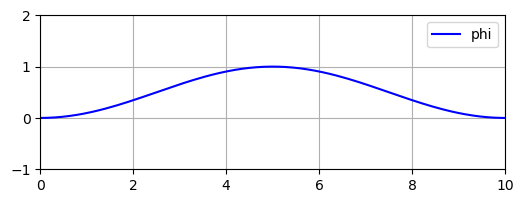

In [ ]:
L   =  10
EI  =  1.e6
mu  =  100

x   =  np.linspace(0, L, 128)
phi = (1 - np.cos(2*np.pi*x/L))/2

plt.figure(1, figsize=(6,2), clear=True)
plt.plot(x, phi, 'b')
plt.axis([0, L, -1, 2])
plt.legend(('phi',))
plt.grid(True)


As derivadas dessa função proposta são:

$$ \varphi'(x)  = \frac{1}{2} \cdot \frac{2\pi}  {L}   \sin{\left( \frac{2\pi  x }{L} \right)} 
                = \frac{\pi}  {L}   \sin{\left(       2\pi \xi     \right)}$$
$$ \varphi''(x) = \frac{2\pi^2}{L^2} \cos{\left( \frac{2\pi  x}{L}   \right)} 
                = \frac{2\pi^2}{L^2} \cos{\left(       2\pi \xi     \right)}$$

onde $\xi = x/L$. 
Portanto, a energia potencial elástica é:

$$ V = \frac{1}{2}   \int_0^L{ EI \left[ \varphi''(x)   \right]^2 \; dx  } 
     = \frac{EIL}{2} \int_0^1{    \left[ \varphi''(\xi) \right]^2 \; d\xi} 
     = \frac{EIL}{2} \cdot \left( \frac{2\pi^2}{L^2} \right)^2 \cdot \frac{1}{2}$$

A energia cinética de referência é:

$$ T_{\rm ref} = \frac{1}{2}     \int_0^L{ \mu \left[ \varphi(x)   \right]^2 \; dx  } 
               = \frac{\mu L}{2} \int_0^1{     \left[ \varphi(\xi) \right]^2 \; d\xi}
               = \frac{\mu L}{2} \cdot \left( \frac{1}{2} \right)^2 \cdot \frac{3}{2}$$

Dividindo as duas formas de energia, chega-se à frequência fundamental:

$$ \frac{V}{T_{\rm ref}} = \omega_1^2 
                         = \frac{\pi^4 EI}{L^3}  \cdot \frac{16}{3\mu L}
                         \approx \left( \frac{4.7742}{L} \right)^4 \frac{EI}{\mu}$$

E portanto:

$$f_1 \approx \frac{1}{2\pi} \left( \frac{4.7742}{L} \right)^2 \sqrt{\frac{EI}{\mu}}


In [19]:
beta  = np.pi *((16./3)**(1/4))

f1 = (1/2/np.pi) * ((beta/L)**2) * np.sqrt(EI/mu)

print(f'Frequência fundamental: {f1:.2f} Hz')

Frequência fundamental: 3.63 Hz


Este resultado é muito próximo ao valor exato, onde ao invés de 4.7742 temos 4.7300, 
o que mostra que a função escolhida tem desempenho satisfatório. 
Observe que o quociente de Rayleigh sempre aproxima a frequência correta "por cima",
sendo que o valor exato só é obtido pela forma modal correta.

## Questão 2b (sistema contínuo, vibração forçada)

Calcule e faça o gráfico do deslocamento no centro do vão para uma força externa aplicada,
$F(t) = F_0 \sin (2\pi f_0 t)$ , com $F_0 = 1{\rm kN}$ e $f_0 = 1{\rm Hz}$. (2.5pts)


### Solução:

A forma modal proposta tem valor unitário no centro do vão ($$). 
Logo, tanto a força modal como o deslocamento modal terão valores idênticos
à força aplicada e ao deslocamento transversal no mesmo ponto, respectivamente.

A resposta dinâmica pode ser obtida por simulação ou com a função de amplificação
dinâmica. Vamos inicialmente usar simulação, com um intervalo de 10s discretizado
em 1024 passos de tempo.


In [20]:
F0 = 1000.
f0 = 1.0

t = np.linspace(0, 10, 1024)
F = F0*np.sin(2 *np.pi*f0*t)

